In [3]:
%load_ext autoreload
%autoreload 2

In [53]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *
from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [5]:
cell_num =27 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 27  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 27

## Step 0: Get loaded data 

In [6]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c27_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c27patch_filt.npy'


In [7]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

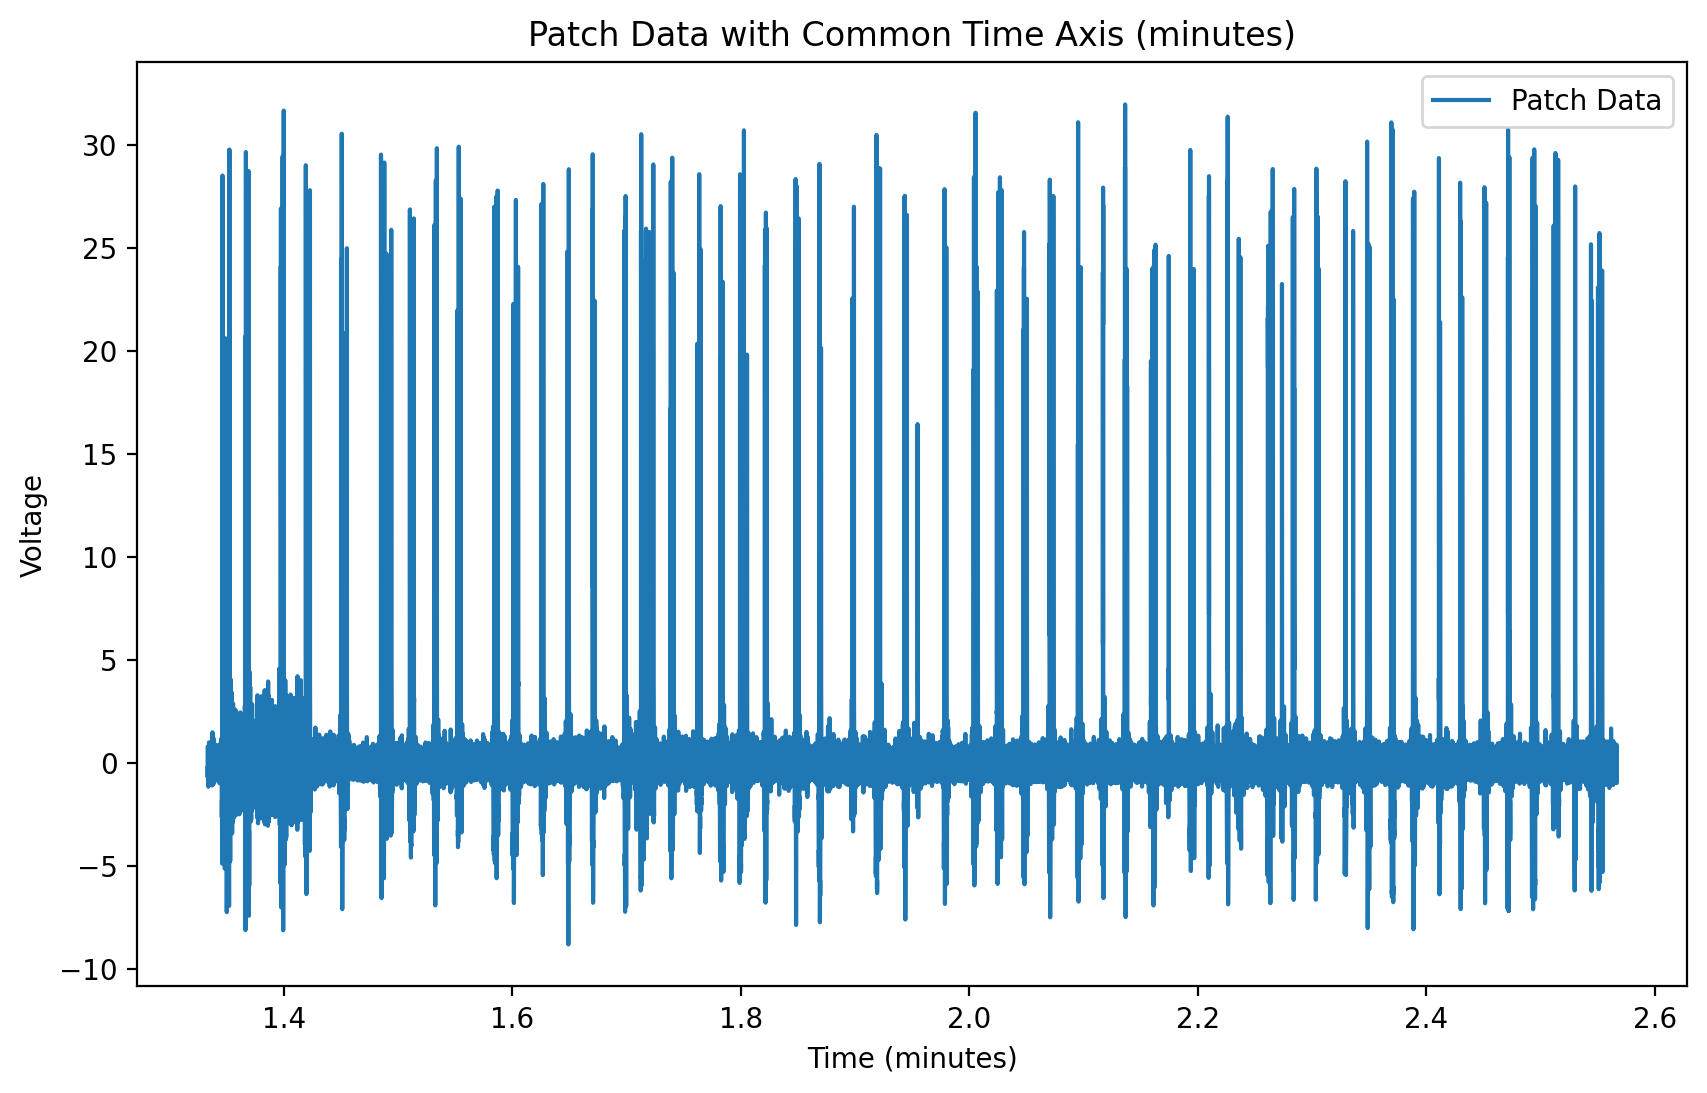

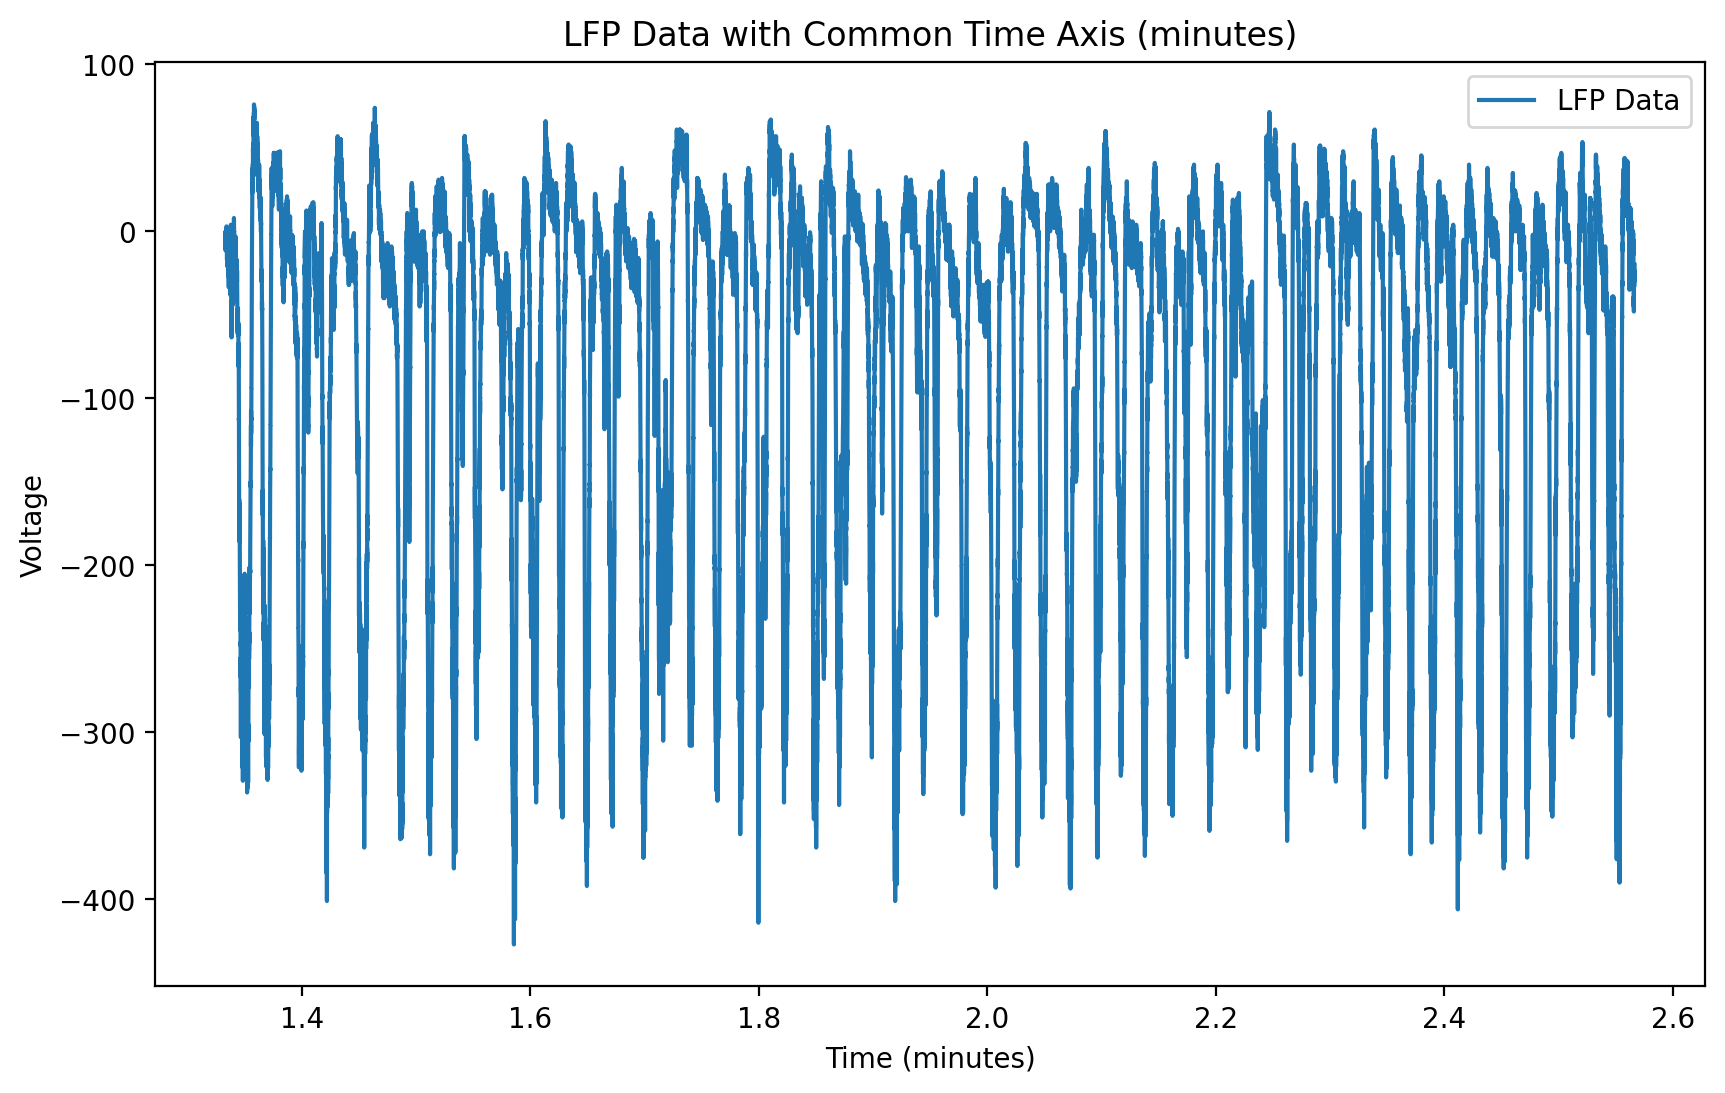

In [8]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

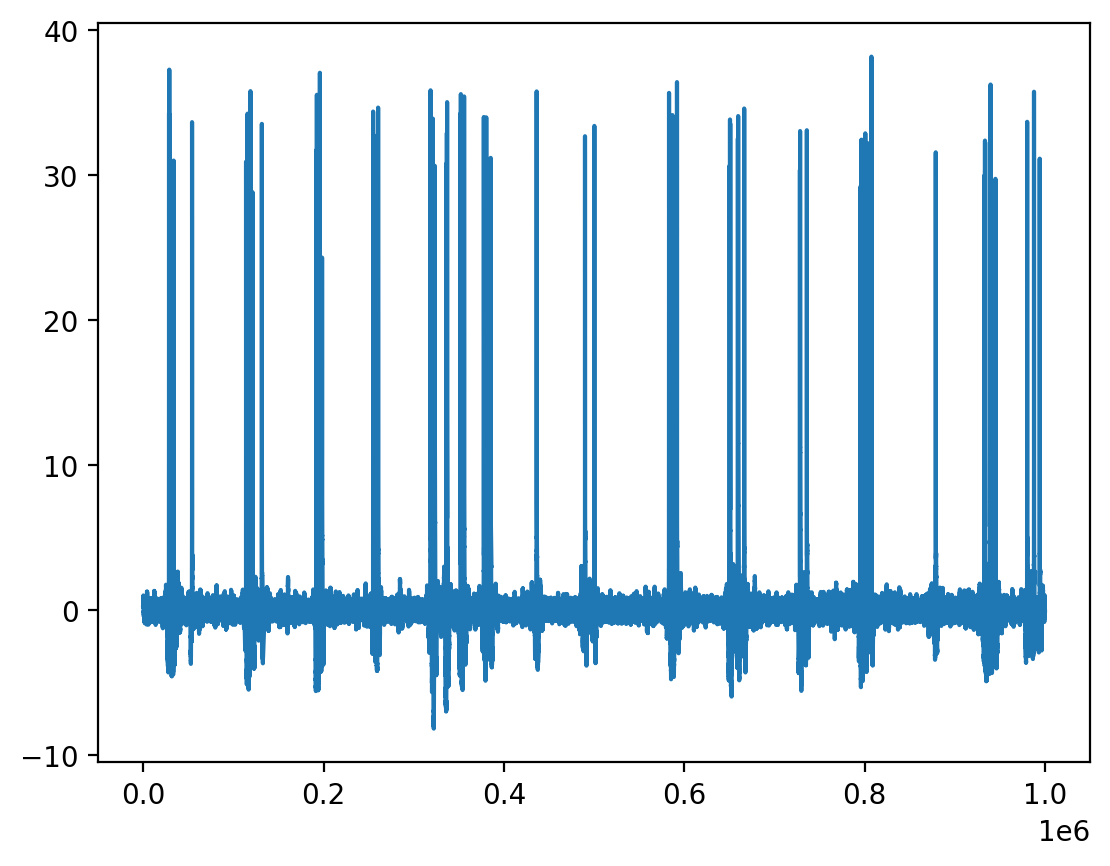

In [10]:
plt.plot(patch_filt[:1000000] )

In [11]:



#threshold in mVs
sp = Spike(thresh_amp=15, window_length=(5., 5.), smooth_frac=.01)

In [12]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|          | 0/1496 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


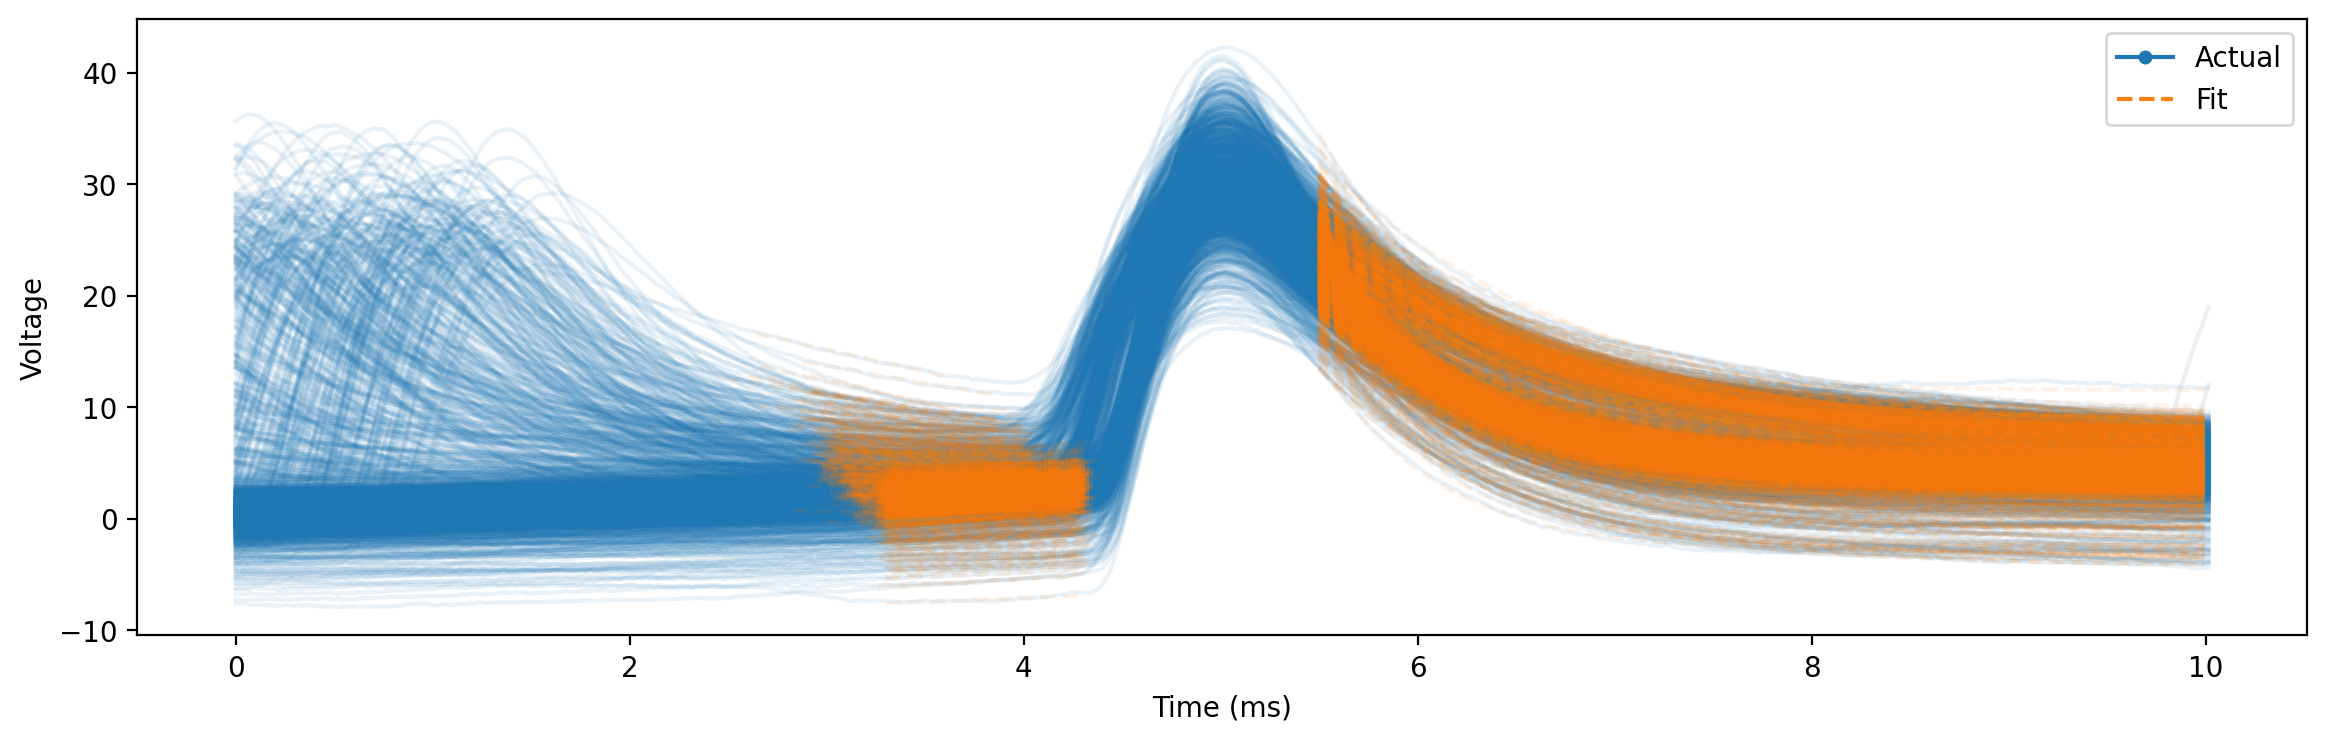

In [18]:
sp.plot()

### Filter spikes 

In [19]:
sp.filter_features()  # Applies default filters in-place

Filtering already applied. Create new instance with inplace=False to re-filter.


### Get spike dataframe (with spike times column)

In [15]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [16]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1
3,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2
4,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3
6,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1491,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405
1492,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406
1493,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407
1494,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408


### Get spike times


In [17]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster ISI spike groups 

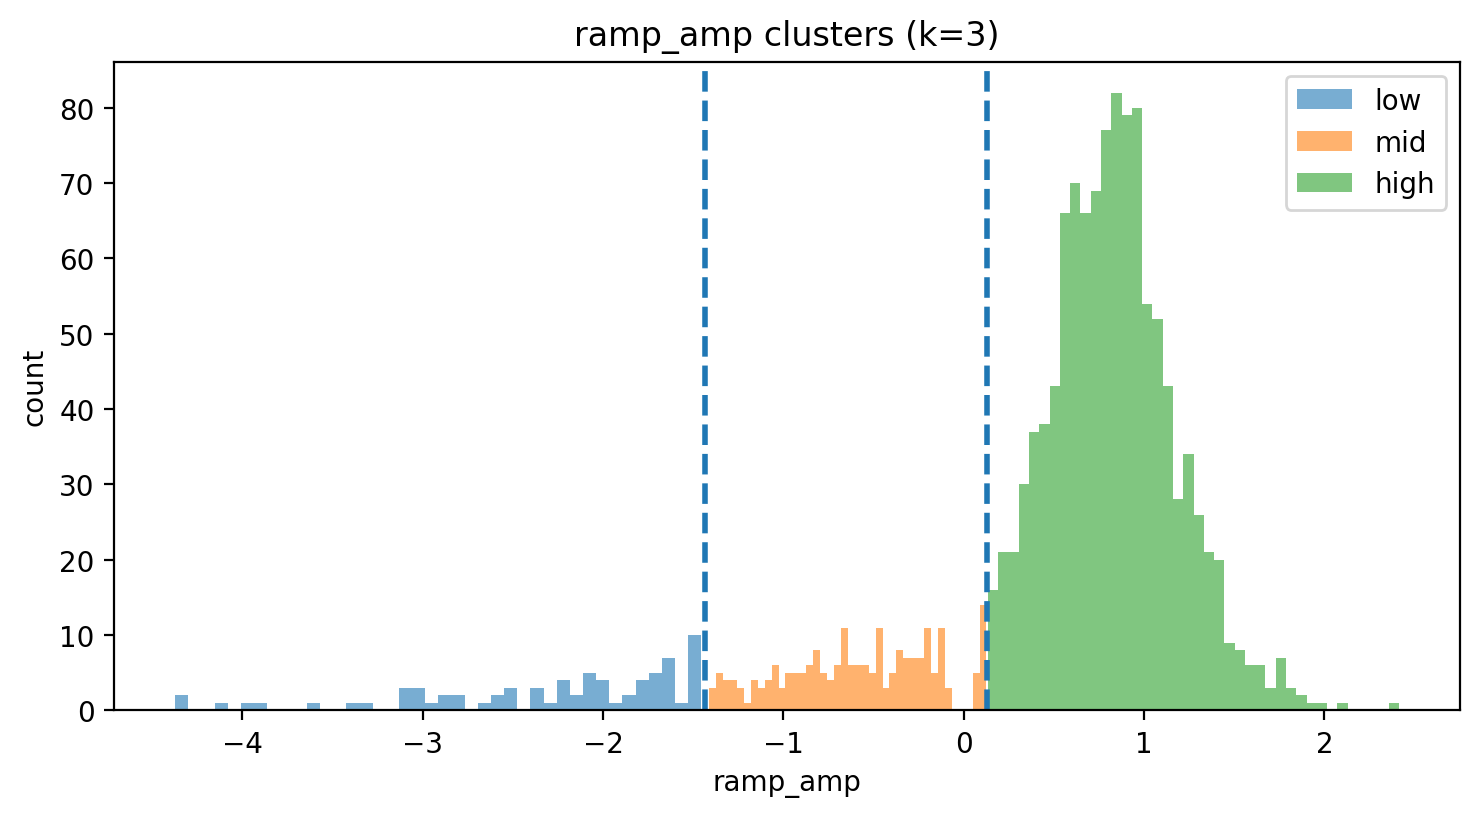

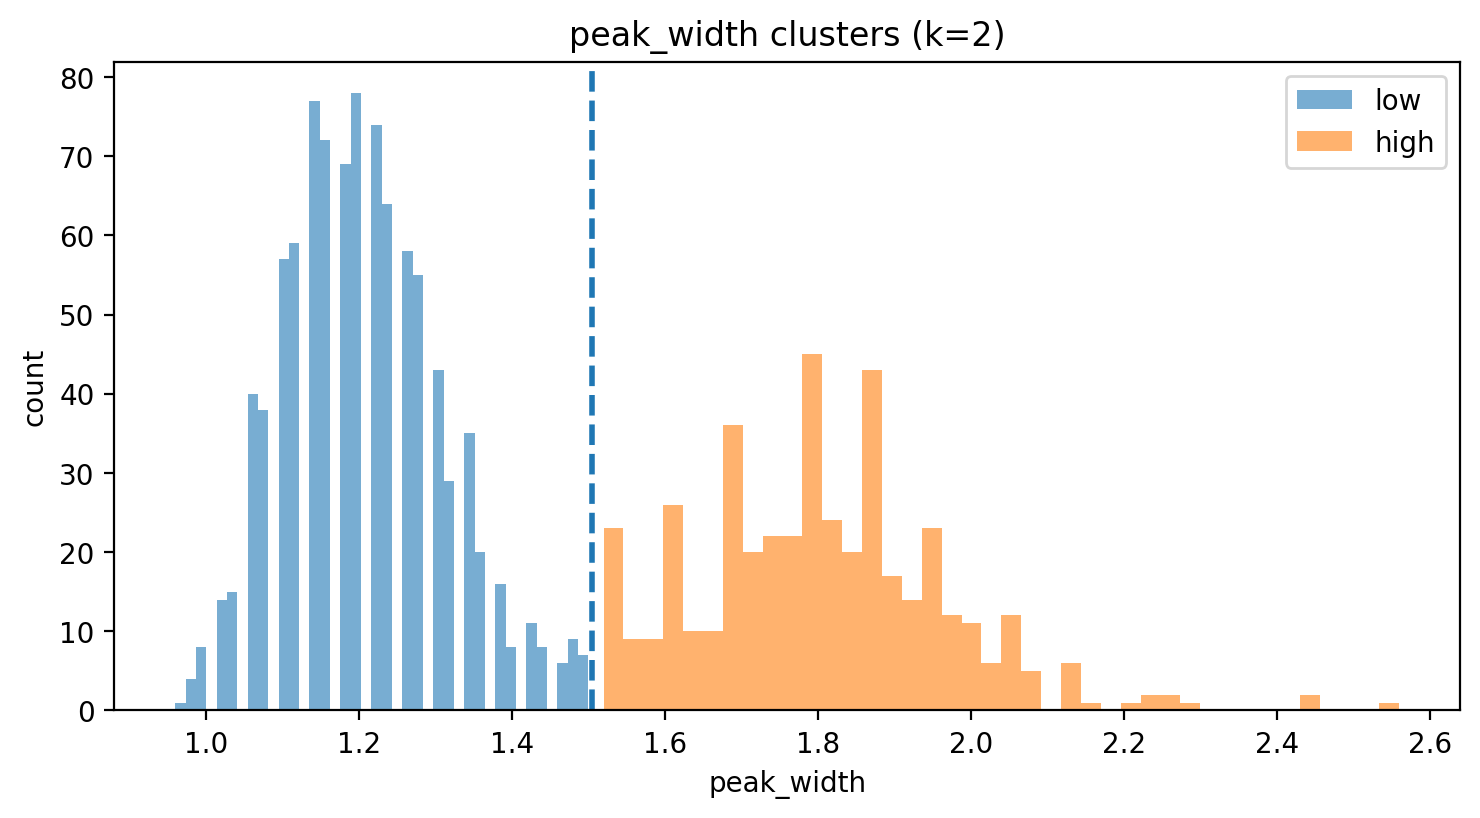

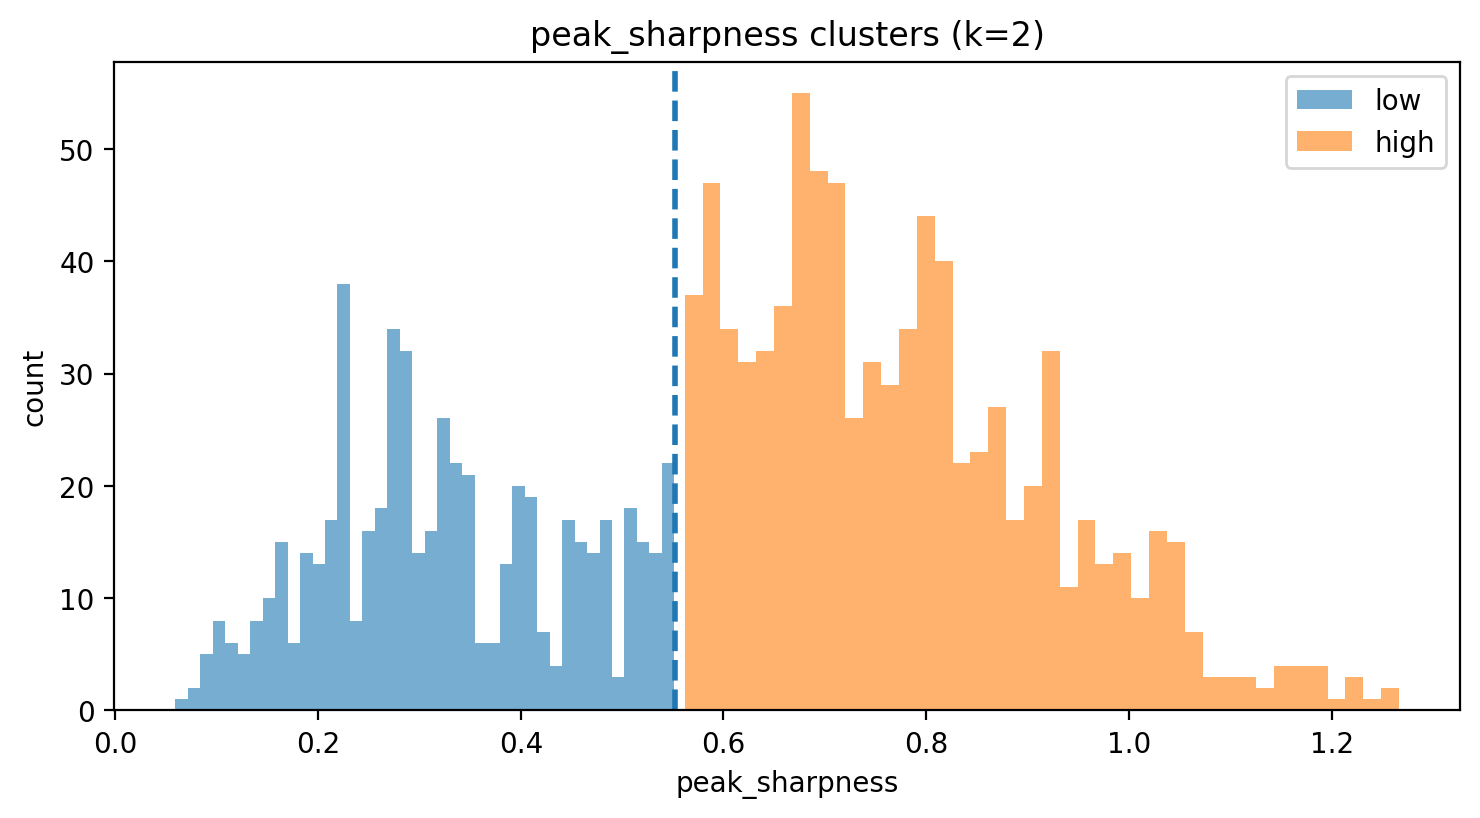

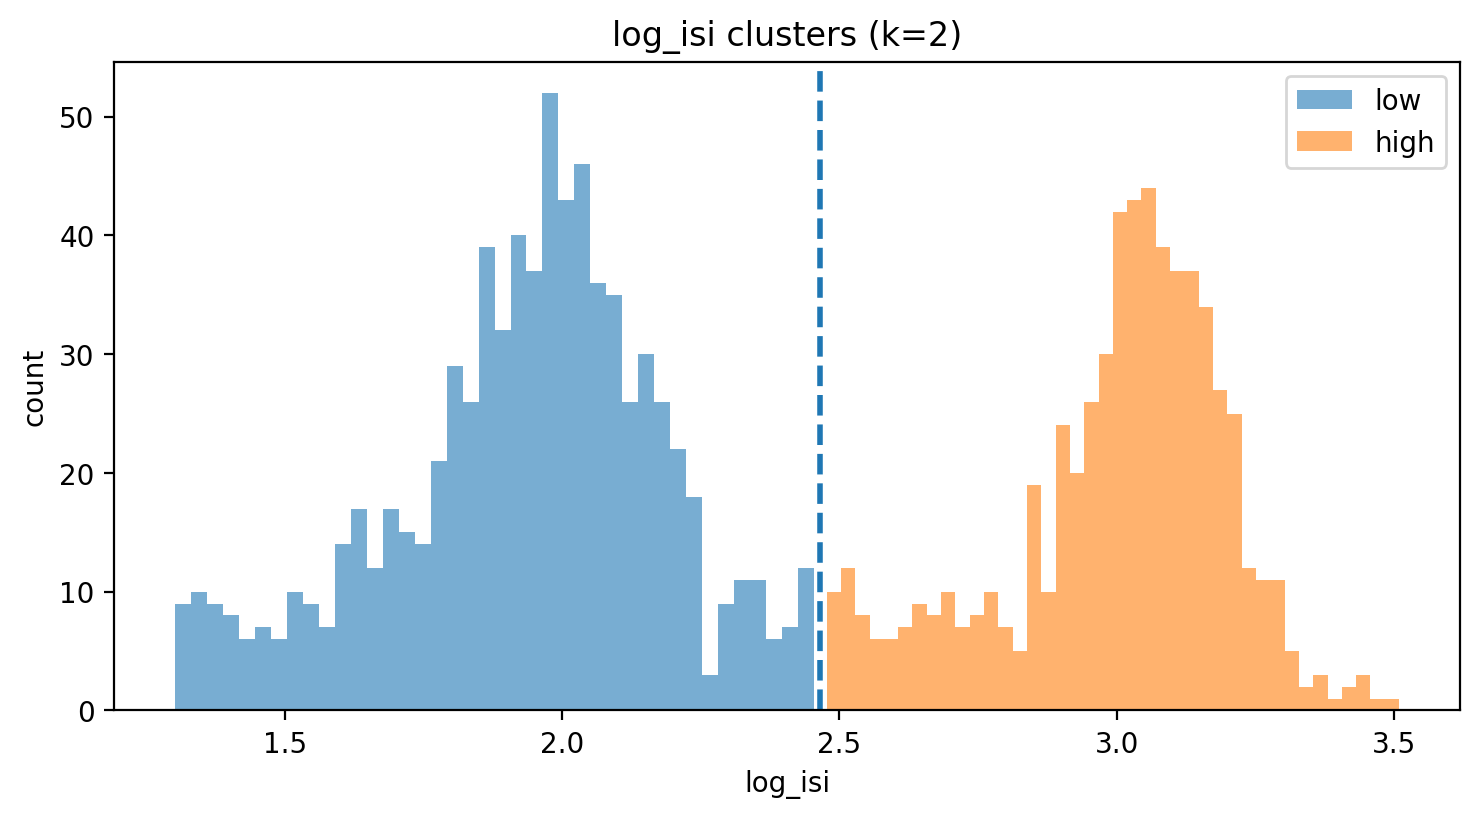

In [49]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=3,
    suffix="_cluster",
    plot_each=True  # set True if you want a quick plot per clustered feature
)







In [51]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,ramp_amp_cluster,peak_width_cluster,peak_sharpness_cluster,log_isi_cluster
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0,high,high,low,low
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1,high,low,high,low
3,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2,high,low,high,high
4,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3,high,low,high,low
6,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4,high,low,high,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405,high,low,high,low
1492,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406,high,low,high,high
1493,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407,high,low,low,low
1494,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408,high,low,high,low


#### Visualize ISI spike cluster groups over time 

In [64]:
def plot_clusters_over_time_min(df, time_col, label_col, time_unit="ms", fs=None,
                                bin_size_ms=1000, sigma_bins=None):
    # ---- extract
    t = pd.to_numeric(df[time_col], errors="coerce").to_numpy(float)
    lab = df[label_col].astype(object).to_numpy()
    valid = np.isfinite(t) & pd.notna(lab)
    if not valid.any():
        print("No valid points.")
        return

    # seconds
    if time_unit == "ms":
        t_sec = t[valid] / 1000.0
    elif time_unit == "samples":
        if not fs or fs <= 0:
            raise ValueError("Provide fs when time_unit='samples'.")
        t_sec = t[valid] / fs
    else:
        raise ValueError("time_unit must be 'ms' or 'samples'.")

    labels = lab[valid].astype(object)
    clusters = [str(x) for x in pd.unique(labels)]

    # bins
    bin_w = bin_size_ms / 1000.0
    t0, t1 = float(np.min(t_sec)), float(np.max(t_sec))
    if np.isclose(t0, t1): t1 = t0 + bin_w
    edges = np.arange(t0, t1 + bin_w, bin_w)
    centers = 0.5*(edges[:-1] + edges[1:])

    def _smooth(x, s):
        if not s or s <= 0: return x
        half = int(np.ceil(4*s))
        g = np.arange(-half, half+1, dtype=float)
        k = np.exp(-0.5*(g/s)**2); k /= k.sum()
        return np.convolve(x, k, mode="same")

    fig, (ax_raster, ax_rate) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                             gridspec_kw={'height_ratios':[1,1.2]})

    # raster
    for i, cl in enumerate(clusters):
        m = (labels == cl)
        if m.sum() == 0: continue
        y = np.full(m.sum(), i+1, float) + (np.random.rand(m.sum())-0.5)*0.03
        ax_raster.scatter(t_sec[m], y, s=4, alpha=0.8, label=str(cl))
    ax_raster.set_yticks(range(1, len(clusters)+1))
    ax_raster.set_yticklabels(clusters)
    ax_raster.set_ylabel("cluster (raster)")
    ax_raster.legend(loc="upper right", fontsize=8)

    # rates
    for cl in clusters:
        m = (labels == cl)
        counts, _ = np.histogram(t_sec[m], bins=edges)
        rate = _smooth(counts/bin_w, sigma_bins)
        ax_rate.plot(centers, rate, label=str(cl))
    ax_rate.set_ylabel("rate (spikes/s)")
    ax_rate.set_xlabel("time (s)")
    ax_rate.legend(loc="upper right", fontsize=9)
    ax_rate.set_xlim(edges[0], edges[-1])
    ttl = f"ISI clusters over time (bin={bin_size_ms} ms"
    if sigma_bins: ttl += f", σ={sigma_bins} bins"
    ttl += ")"
    fig.suptitle(ttl, y=0.98)
    plt.tight_layout()
    plt.show()


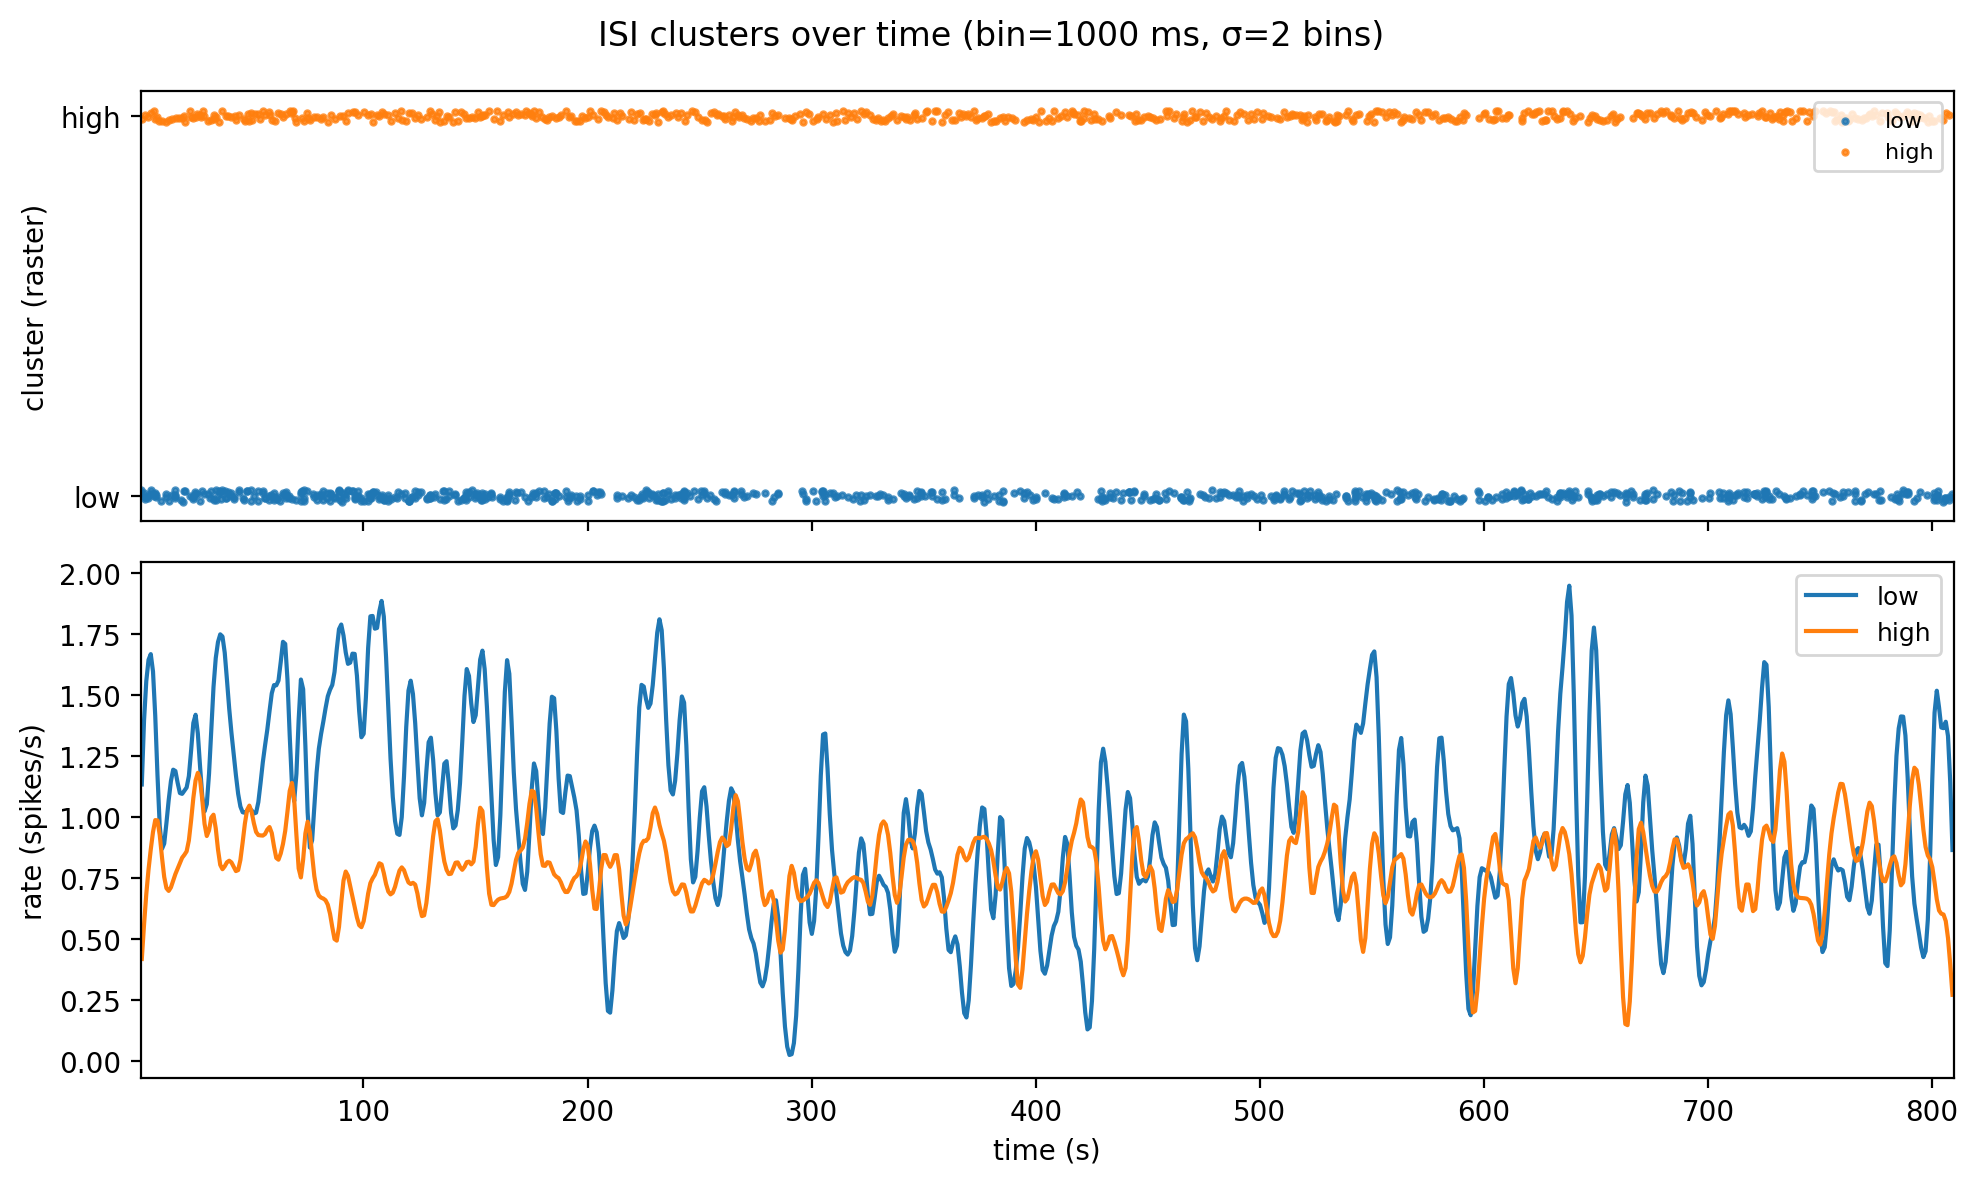

In [65]:
plot_clusters_over_time_min(
    df_features_clust,
    time_col="spk_times_ms",
    label_col="log_isi_cluster",   # your labels are 'low'/'high'
    time_unit="ms",
    bin_size_ms=1000,
    sigma_bins=2
)


In [68]:
def isi_transition_matrix(df, cluster_col="log_isi_cluster"):
    seq = df[cluster_col].dropna().astype(str).to_numpy()
    clusters = sorted(np.unique(seq))
    n = len(clusters)
    mat = np.zeros((n, n))
    for a, b in zip(seq[:-1], seq[1:]):
        i, j = clusters.index(a), clusters.index(b)
        mat[i, j] += 1
    mat = mat / mat.sum(axis=1, keepdims=True)
    return pd.DataFrame(mat, index=clusters, columns=clusters)

# Example
trans_mat = isi_transition_matrix(df_features_clust, "log_isi_cluster")
print(trans_mat)


          high       low
high  0.279743  0.720257
low   0.569975  0.430025


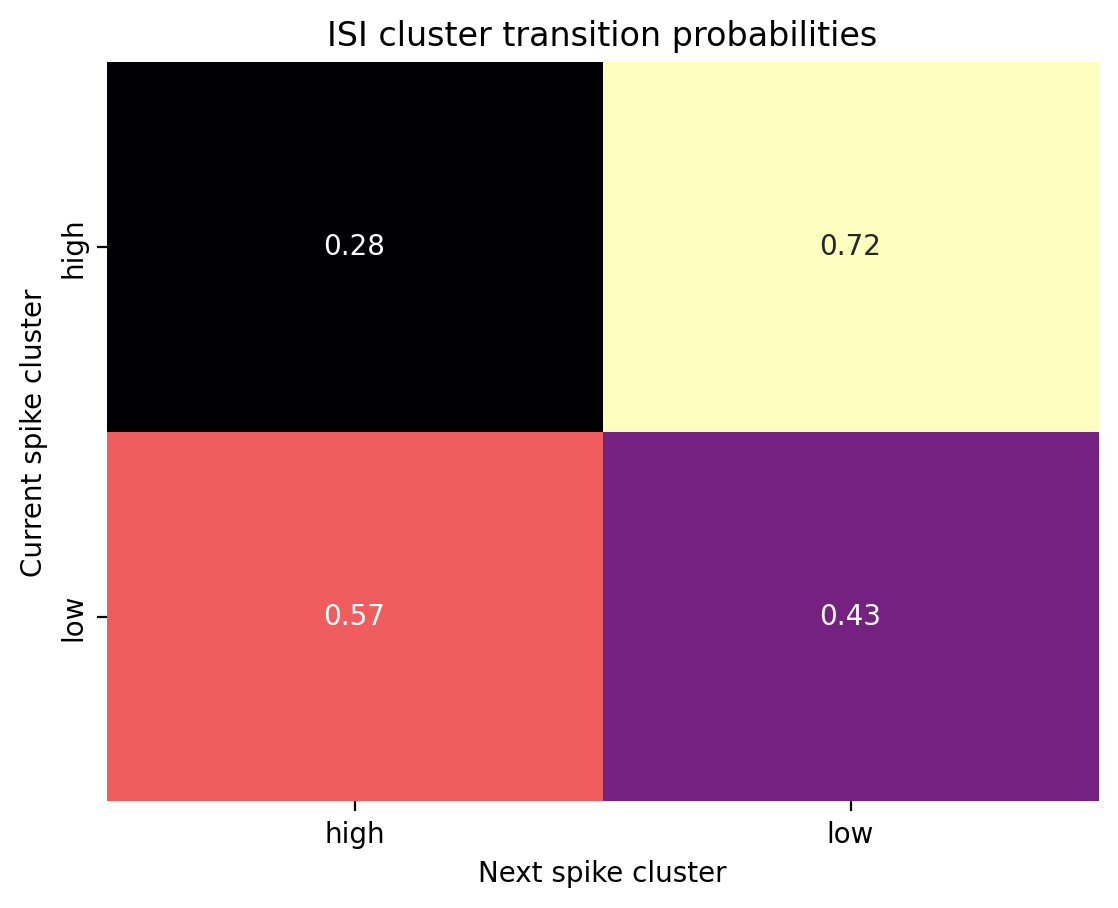

In [69]:
sns.heatmap(trans_mat, annot=True, cmap="magma", cbar=False)
plt.title("ISI cluster transition probabilities")
plt.xlabel("Next spike cluster")
plt.ylabel("Current spike cluster")
plt.show()


In [105]:


def mark_high_burst_onsets(
    df: pd.DataFrame,
    cluster_col: str = "log_isi_cluster",
    time_col: str = "spk_times_ms",
    min_low_run: int = 1,
) -> pd.DataFrame:
    """
    Mark HIGH spikes that are immediately followed by ≥min_low_run LOW spikes.
    Assumes df[time_col] is in seconds.
    """
    out = df.copy().sort_values(time_col).reset_index(drop=True)
    labs = out[cluster_col].astype(object).to_numpy()

    n = len(labs)
    is_low = labs == "low"
    next_low_all = np.zeros(n, dtype=bool)

    if n > min_low_run:
        for i in range(n - min_low_run):
            if labs[i] == "high" and np.all(is_low[i + 1 : i + 1 + min_low_run]):
                next_low_all[i] = True

    out["is_long_to_short_isi_onset"] = next_low_all
    return out


def plot_long_to_short_isi_onsets(
    df_marked: pd.DataFrame,
    time_col: str = "spk_times_ms",          # always in milliseconds
    cluster_col: str = "log_isi_cluster",
    time_range: Optional[Tuple[float, float]] = None,  # in seconds
    show_counts: bool = True,
):
    """
    Plot spike timeline (x-axis in SECONDS), color by ISI cluster,
    and circle LONG-ISI (high) spikes that start a run of SHORT-ISI (low) spikes.

    Parameters
    ----------
    df_marked : DataFrame
        Must include columns for time_col, cluster_col, and 'is_long_to_short_isi_onset'.
    time_col : str
        Column containing spike times in milliseconds.
    time_range : (float, float)
        Time window in seconds to display.
    """

    color_map = {"low": "#1f77b4", "high": "#ff7f0e"}

    # --- convert from ms → s
    t_sec_all = pd.to_numeric(df_marked[time_col], errors="coerce").to_numpy(float) / 1000.0
    valid = np.isfinite(t_sec_all) & df_marked[cluster_col].notna()
    t_sec_all = t_sec_all[valid]
    labels_all = df_marked.loc[valid, cluster_col].astype(str).to_numpy()
    colors_all = np.array([color_map.get(lbl, "gray") for lbl in labels_all], dtype=object)

    # --- find long→short ISI onsets (the LONG spikes)
    onset_mask_all = valid & (df_marked["is_long_to_short_isi_onset"] == True)
    t_on_sec_all = pd.to_numeric(df_marked.loc[onset_mask_all, time_col], errors="coerce").to_numpy(float) / 1000.0

    # --- apply time window (seconds)
    if time_range is not None:
        tmin, tmax = map(float, time_range)
        in_window = (t_sec_all >= tmin) & (t_sec_all <= tmax)
        t_plot = t_sec_all[in_window]
        colors = colors_all[in_window]
        in_window_on = (t_on_sec_all >= tmin) & (t_on_sec_all <= tmax)
        t_on = t_on_sec_all[in_window_on]
    else:
        t_plot, colors, t_on = t_sec_all, colors_all, t_on_sec_all
        tmin, tmax = (t_sec_all.min(), t_sec_all.max()) if t_sec_all.size else (0.0, 1.0)

    # --- plot
    fig, ax = plt.subplots(figsize=(11, 2.6))
    if t_plot.size:
        ax.scatter(t_plot, np.ones_like(t_plot), s=6, c=colors, alpha=0.85)
    if t_on.size:
        ax.scatter(t_on, np.ones_like(t_on), s=60,
                   facecolors="none", edgecolors="black", linewidths=1.4,
                   label="LONG→SHORT onset (LONG spike)")

    ax.set_xlim(tmin, tmax)
    ax.set_xlabel("time (s)")
    ax.set_yticks([])

    title = f"Burst onsets: LONG→SHORT ISI ({tmin:.0f}–{tmax:.0f} s)"
    if show_counts:
        title += f"   [spikes: {t_plot.size}, onsets: {t_on.size}]"
    ax.set_title(title)

    if t_plot.size == 0 and t_on.size == 0:
        ax.text(0.5, 0.5, "No spikes / onsets in selected window",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=11, color="gray", alpha=0.8)

    if t_on.size:
        ax.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()



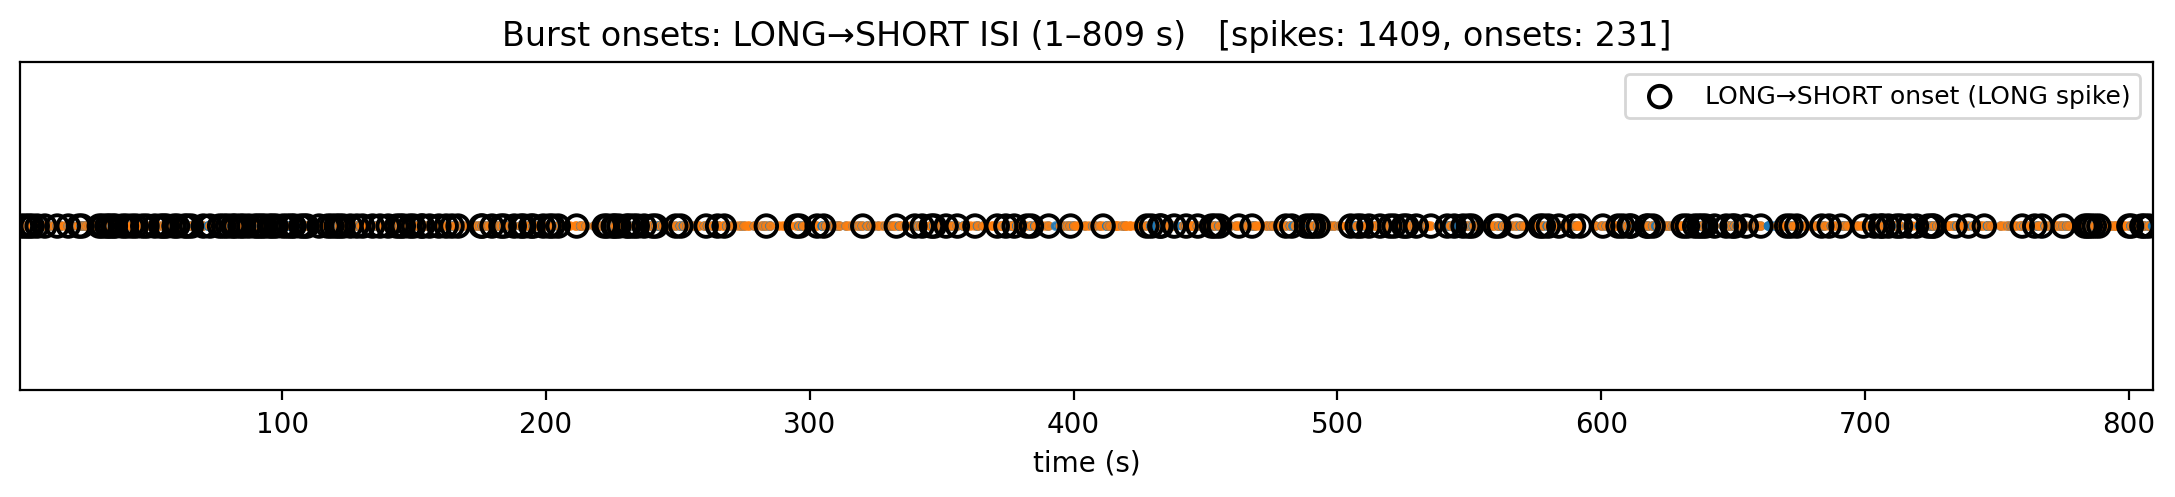

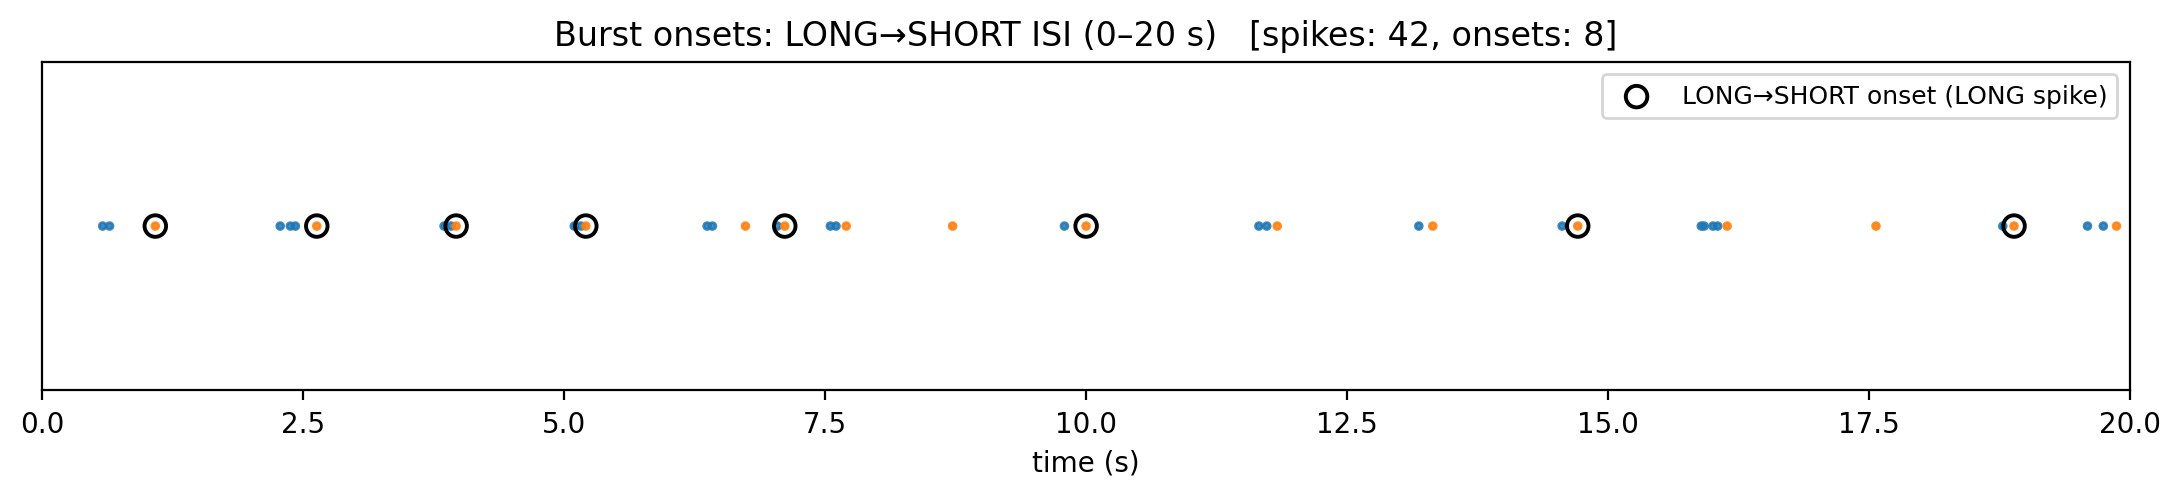

In [107]:
# Identify high spikes that start low bursts
df_marked = mark_high_burst_onsets(
    df_features_clust,
    cluster_col="log_isi_cluster",
    time_col="spk_times_ms",
    min_low_run=2  # how many LOW spikes must follow to count as a burst
)

# Plot full timeline
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster"          

)


# Zoom into a specific range 
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster",
    time_range=(00, 20)  # seconds
)


In [94]:
df_marked

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,ramp_amp_cluster,peak_width_cluster,peak_sharpness_cluster,log_isi_cluster,is_high_burst_onset
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0,high,high,low,low,False
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1,high,low,high,low,False
2,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2,high,low,high,high,True
3,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3,high,low,high,low,False
4,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4,high,low,high,low,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405,high,low,high,low,False
1406,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406,high,low,high,high,True
1407,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407,high,low,low,low,False
1408,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408,high,low,high,low,False
